# Notebook 3 — Modèle avancé : DistilBERT (Transformer)

> IMPORTANT: pour ce notebook, on te recommande fortement (sauf si tu souhaites attendre 10h d'entrainement...) d'utiliser [Google Colab](https://colab.research.google.com/)
>
> - En haut à droite, sélectionne un TPU (gratuit).
> - Dans "fichiers", crée un dossier "data" et mets "train.csv", "val.csv", et "test.csv" dans ce dossier.

Dans le notebook précédent, tu as entraîné des modèles de machine learning classiques avec TF-IDF. Ils fonctionnaient bien, mais avaient une grosse limitation : ils ne comprennent **ni l'ordre des mots, ni le contexte**.

Par exemple, TF-IDF ne voit aucune différence entre :
- \"Your account **is** suspended\" (ton compte est suspendu)
- \"Your account **is not** suspended\" (ton compte n'est pas suspendu)

Pour résoudre ce problème, on va utiliser les **Transformers** !

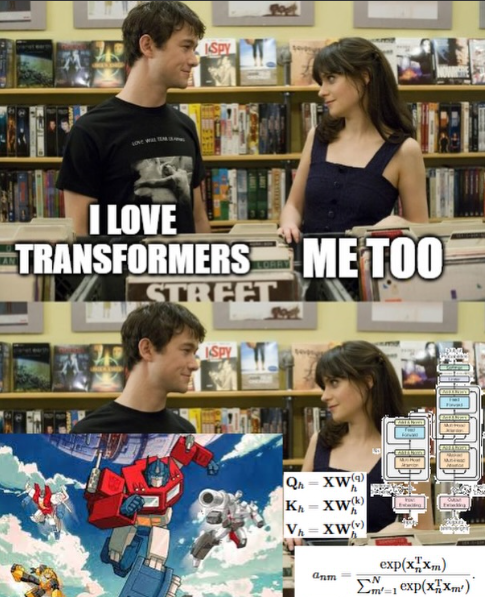

Les **Transformers** sont une famille de modèles de deep learning qui comprennent le contexte des phrases. Ils sont entrainés sur de grosses quantités de données pour pouvoir comprendre la logique d'un langage.

Aujourd'hui, on va utiliser **DistilBERT**, une version légère et rapide du célèbre modèle BERT (si tu veux plus d'infos sur BERT, c'est [par ici](https://medium.com/@skillcate/bert-for-dummies-state-of-the-art-model-from-google-42639953e769)).

---

## Ce que tu vas apprendre dans ce notebook

1. Qu'est-ce qu'un **Transformer**.
2. Comment utiliser **DistilBERT** pour classer des emails.
3. Comment **fine-tuner** (ou adapter) un modèle pré-entraîné (c'est-à-dire entrainé sur une autre source de données au préalable).
4. Comment comparer les résultats avec les modèles classiques du Notebook 2.

---

## 1 — C'est quoi un Transformer ?

> Avec la hype actuelle autour de l'IA, pas très compliqué de trouver des articles sur les transformers. Je t'en propose deux :
>
> - [DataCamp](https://www.datacamp.com/fr/tutorial/how-transformers-work)
> - [TowardsDataScience](https://towardsdatascience.com/transformers-explained-visually-part-1-overview-of-functionality-95a6dd460452/)

### L'idée clé : l'attention

Quand tu lis la phrase \"*Click here to verify **your** account*\" (= \"Clique ici pour vérifier ton compte\"), tu comprends que \"your\" se rapporte à \"account\". Un modèle TF-IDF ne voit que des mots isolés. Donc, il ne comprends pas le lien entre les mots !

Un Transformer, lui, utilise un mécanisme appelé l'**attention** qui permet à chaque mot de \"regarder\" tous les autres mots de la phrase pour mieux comprendre le sens.

### BERT et DistilBERT

**DistilBERT** est une version \"distillée\" de BERT : plus petit, plus rapide, mais presque aussi performant. C'est un excellent choix pour débuter avec les Transformers (et éviter le besoin d'avoir un ordinateur superpuissant !).

| | BERT | DistilBERT |
|---|---|---|
| **Créé par** | Google (2018) | Hugging Face (2019) |
| **Taille** | 110 millions de paramètres | 66 millions de paramètres |
| **Vitesse** | Plus lent | ~60% plus rapide |
| **Performance** | Très élevée | ~97% de la performance de BERT |

### Le principe du fine-tuning

DistilBERT a déjà été entraîné sur d'énormes quantités de texte (Wikipédia, livres, etc.). Il \"comprend\" déjà l'anglais.

On va l'**adapter** (ce qu'on appelle le *fine-tuning*) à notre tâche spécifique (détecter le phishing). C'est comme si on prenait quelqu'un qui parle déjà couramment anglais et on lui apprenait à reconnaître les arnaques.

---

## 2 — Mise en place

On va utiliser la bibliothèque **Hugging Face Transformers**, qui rend l'utilisation de ces modèles avancés très simple.

In [ ]:
# Installation des bibliothèques nécessaires (si pas déjà installées)
!pip install transformers datasets accelerate -q

In [ ]:
# Importer les librairies dont on a besoin pour ce notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

# Import ici les éléments nécessaires de scikit-learn et de transformers pour la tokenisation, les modèles et les métriques
# TODO: à toi de compléter par le bon code
from transformers import TrainingArguments
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings("ignore")

# On charge les données d'entraînement, de validation et de test, comme avant
train = pd.read_csv("data_training/train.csv")
val = pd.read_csv("data_training/val.csv")
test = pd.read_csv("data_training/test.csv")

print(f"Entraînement : {len(train):,} emails")
print(f"Validation : {len(val):,} emails")
print(f"Test : {len(test):,} emails")

---

## 3 — Tokenisation avec DistilBERT

Les Transformers n'utilisent pas TF-IDF. Ils ont leur propre façon de transformer le texte en nombres, appelée **tokenisation par sous-mots**.

Au lieu de découper en mots entiers, DistilBERT découpe en **morceaux de mots** (sub-words). Par exemple :
- \"unhappiness\" → [\"un\", \"##happiness\"]
- \"phishing\" → [\"phi\", \"##shing\"]

Cela permet au modèle de comprendre même des mots qu'il n'a jamais vus (par exemple, s'il n'a jamais vu \"unhappiness\" mais qu'il a vu \"happiness\").

In [ ]:
MODEL_NAME = "distilbert-base-uncased"

# On charge le tokeniseur du modèle pré-entraîné
tokenizer = None    # TODO: à toi de compléter par le bon code

# Voyons comment le tokeniseur découpe un exemple
example = "URGENT: Verify your PayPal account immediately!"
tokens = tokenizer.tokenize(example)
token_ids = tokenizer.encode(example)

print(f"Texte original : {example}")
print(f"Tokens : {tokens}")
print(f"IDs numériques : {token_ids}")
print(f"Nombre de tokens : {len(tokens)}")

### Préparons les données pour DistilBERT

On doit convertir notre DataFrame pandas en un format que Hugging Face comprend : un `Dataset`.

In [ ]:
# On convertit nos DataFrames en objets Dataset de Hugging Face
train_dataset = None    # TODO: à toi de compléter par le bon code
val_dataset = None    # TODO: à toi de compléter par le bon code
test_dataset = None    # TODO: à toi de compléter par le bon code

print(f"Dataset d'entraînement : {train_dataset}")
print(f"\nExemple :\n{train_dataset[0]}")

In [ ]:
# On tronque les emails à 256 tokens max pour que ce soit rapide
MAX_LENGTH = 256

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
    )

print("Tokenisation en cours...")
train_tokenized = train_dataset.map(tokenize_function, batched=True)
val_tokenized = val_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)
print("\u2713 Tokenisation terminée !")

print(f"\nColonnes du dataset tokenisé : {train_tokenized.column_names}")
print(f"Forme d'un exemple d'input_ids : {len(train_tokenized[0]['input_ids'])} tokens")

---

## 4 — Chargement du modèle DistilBERT

On charge DistilBERT pré-entraîné et on ajoute une **tête de classification** dessus. C'est une petite couche supplémentaire qui transforme la représentation interne du modèle en une décision binaire (sûr / phishing).

In [ ]:
# On charge le modèle de classification de séquences pré-entraîné (avec une tête de classification adaptée à notre tâche, et 2 classes : sûr et phishing)
model = None    # TODO: à toi de compléter par le bon code

# Comptons les paramètres
n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModèle chargé : {MODEL_NAME}")
print(f"Paramètres totaux : {n_params:>12,}")
print(f"Paramètres entraînables : {n_trainable:>12,}")
print(f"\nC'est {n_params/1e6:.0f} millions de paramètres !")

Si tu compares ça avec nos modèles TF-IDF qui n'avaient que quelques milliers de poids, c'est quand même beaucoup. Mais est-ce que ça vaut le coup ?

---

## 5 — Entraînement (fine-tuning)

On va entraîner le modèle pendant **2 epochs** (2 passages complets sur les données d'entraînement). C'est généralement suffisant pour le
fine-tuning car le modèle sait déjà beaucoup de choses.

### Les paramètres importants

| Paramètre | Valeur | Explication |
|---|---|---|
| `num_train_epochs` | 2 | Nombre de fois qu'on parcourt toutes les données |
| `learning_rate` | 2e-5 | Vitesse d'apprentissage (petit = apprentissage prudent) |
| `per_device_train_batch_size` | 16 | Nombre d'emails traités en même temps |
| `weight_decay` | 0.01 | Régularisation pour éviter le sur-apprentissage |

In [ ]:
def compute_metrics(eval_pred):
    """ Calcule les métriques pendant l'entrainement. """
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    # On retourne un dictionnaire avec les métriques que l'on veut suivre pendant l'entrainement (ceux du notebook précédent)
    return {
        "accuracy": None,    # TODO: à toi de compléter par le bon code
        "precision": None,    # TODO: à toi de compléter par le bon code
        "recall": None,    # TODO: à toi de compléter par le bon code
        "f1": None    # TODO: à toi de compléter par le bon code
    }

# Les arguments pour l'entrainement
training_args = TrainingArguments(
    output_dir="./distilbert_phishing",
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    report_to="none",
    optim="adamw_torch",
    dataloader_drop_last=False
)

# La classe qui va nous permettre d'entrainer le modèle, en gérant tout le processus d'entrainement, d'évaluation et de sauvegarde automatiquement
trainer = None    # TODO: à toi de compléter par le bon code

print("\u2500"*50)
print("  Début du fine-tuning de DistilBERT")
print("  Cela peut prendre quelques minutes...")
print("\u2500"*50)

trainer.train()
print("\n\u2713 Entrainement terminé !")

---

## 6 — Évaluation sur la validation

Regardons comment DistilBERT s'en sort sur l'ensemble de validation.

In [ ]:
# On évalue le modèle sur le set de validation
val_results = None    # TODO: à toi de compléter par le bon code

print("\n" + "="*50)
print("  Résultats de DistilBERT (Validation)")
print("="*50)
print(f"  Accuracy : {val_results['eval_accuracy']:.4f}  ({val_results['eval_accuracy']*100:.1f}%)")
print(f"  Précision : {val_results['eval_precision']:.4f}  ({val_results['eval_precision']*100:.1f}%)")
print(f"  Rappel : {val_results['eval_recall']:.4f}  ({val_results['eval_recall']*100:.1f}%)")
print(f"  F1-score : {val_results['eval_f1']:.4f}  ({val_results['eval_f1']*100:.1f}%)")

---

## 7 — Évaluation finale sur le test

Comme dans le Notebook 2, on peut maintenant évaluer une dernière fois sur l'ensemble de test.

In [ ]:
# On predit les classes sur le set de test (celles avec les plus hautes probabilités)
test_output = trainer.predict(test_tokenized)
y_pred_bert = np.argmax(test_output.predictions, axis=-1)

y_test = test_output.label_ids

# On calcule les métriques sur le set de test
acc = None    # TODO: à toi de compléter par le bon code
prec = None    # TODO: à toi de compléter par le bon code
rec = None    # TODO: à toi de compléter par le bon code
f1 = None    # TODO: à toi de compléter par le bon code

print("\n" + "="*50)
print("  Résultats de DistilBERT (TEST FINAL)")
print("="*50)
print(f"  Accuracy : {acc:.4f}  ({acc*100:.1f}%)")
print(f"  Précision : {prec:.4f}  ({prec*100:.1f}%)")
print(f"  Rappel : {rec:.4f}  ({rec*100:.1f}%)")
print(f"  F1-score : {f1:.4f}  ({f1*100:.1f}%)")

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

# On crée la matrice de confusion pour le meilleur modèle sur l'ensemble de test
cm = None    # TODO: à toi de compléter par le bon code
disp = None    # TODO: à toi de compléter par le bon code

# On affiche la matrice de confusion
disp.plot(ax=ax, cmap="Purples", colorbar=False)
ax.set_title("Matrice de confusion \u2014 DistilBERT (Test)", fontsize=13)
ax.set_xlabel("Prédiction du modèle")
ax.set_ylabel("Étiquette réelle")
plt.tight_layout()
plt.show()

print("\nRapport de classification détaillé :\n")
print(classification_report(y_test, y_pred_bert, target_names=["S\u00fbr", "Phishing"]))

---

## 8 — Comparaison : TF-IDF vs. DistilBERT

Comparons maintenant les résultats de DistilBERT avec le meilleur modèle TF-IDF du Notebook (partie 2).

> **Note :** pour cette comparaison, entre les résultats du Notebook (partie 2) manuellement si le kernel a été redémarré.

In [ ]:
# NOTE: Remplis ici les résultats de ton meilleur modèle TF-IDF (Notebook (partie 2))
# Remplace les valeurs ci-dessous par celles que tu as obtenues. (Si tu ne les as plus, re-exécute le Notebook (partie 2) et note-les.)

tfidf_results = {
    "nom": "Meilleur TF-IDF (Notebook 2)",
    "accuracy": 0.00,   # à remplacer
    "precision": 0.00,  # à remplacer
    "rappel": 0.00,     # à remplacer
    "f1": 0.00,         # à remplacer
}

bert_results = {
    "nom": "DistilBERT",
    "accuracy": acc,
    "precision": prec,
    "rappel": rec,
    "f1": f1,
}

all_results = [tfidf_results, bert_results]

In [ ]:
metrics = ["Accuracy", "Précision", "Rappel", "F1-score"]

x = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 5))

for i, result in enumerate(all_results):
    values = [result["accuracy"], result["precision"], result["rappel"], result["f1"]]
    bars = ax.bar(x + i*width, [v*100 for v in values], width, label=result["nom"], edgecolor="white")
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f"{val*100:.1f}", ha="center", fontsize=10, fontweight="bold")

ax.set_ylabel("Score (%)")
ax.set_title("TF-IDF vs. DistilBERT \u2014 Ensemble de test", fontsize=14)
ax.set_xticks(x + width/2)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 105)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.2), ncol=2)
plt.tight_layout()
plt.show()

---

## 9 — Expérimente : change un paramètre !

Essaie de modifier **un** paramètre et observe l'effet. Voici quelques idées :

| Ce que tu peux changer | Comment | Ce qui pourrait se passer |
|---|---|---|
| **Nombre d'epochs** | Change `num_train_epochs=2` → `3` | Le modèle apprend plus longtemps (mieux ou sur-apprentissage ?) |
| **Vitesse d'apprentissage** | Change `learning_rate=2e-5` → `5e-5` | Apprentissage plus rapide mais moins stable |
| **Longueur max des tokens** | Change `MAX_LENGTH=256` → `128` | Plus rapide mais perd le contenu des longs emails |

Pour tester, modifie la valeur dans les cellules ci-dessus et re-exécute à partir de la section 5.

> **Astuce :** change un seul paramètre à la fois pour comprendre son effet. Si tu changes tout d'un coup, tu ne sauras pas ce qui a fait la différence.

---

## 10 — Testons avec nos propres emails !

Comme dans le Notebook 2, testons le modèle DistilBERT avec des emails personnalisés.

In [ ]:
def predict_email(text):
    """ Prédit si un email est sûr ou phishing avec DistilBERT. """
    # On tokenise le texte d'entrée
    inputs = None    # TODO: à toi de compléter par le bon code

    device = model.device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=-1)
    
    # La prédiction est la classe avec la plus haute probabilité, et on récupère aussi la confiance associée
    pred = None    # TODO: à toi de compléter par le bon code
    confidence = None    # TODO: à toi de compléter par le bon code

    return pred, confidence

# NOTE: Tu peux modifier ces emails et en ajouter d'autres si tu veux !
my_emails = [
    "URGENT: Your account has been compromised! Click here immediately to verify your identity or your account will be suspended.",
    "Hi team, just a reminder about tomorrow's meeting at 2pm. Please bring your laptops.",
    "Congratulations! You've won a $500 Amazon gift card. Click the link below to claim your prize now.",
    "Dear customer, your package has been shipped and will arrive on Thursday. Track your order here.",
]

print("Prédictions de DistilBERT :\n")
for email in my_emails:
    pred, conf = predict_email(email)
    label = "PHISHING" if pred == 1 else "SÛR     "
    preview = email[:120] + ("..." if len(email) > 120 else "")
    print(f"  {label}  (confiance: {conf*100:3.0f}%) \u2502  {preview}")

### Questions pour toi

- Est-ce que DistilBERT gère mieux le dernier email que le modèle TF-IDF ?
- La confiance du modèle est-elle toujours justifiée ? Peut-on se fier uniquement au pourcentage ?

---

## 11 — Réflexion et conclusion

Voici quelques questions supplémentaires qui peuvent aggrémenter ton rapport :

1. **DistilBERT est-il meilleur que TF-IDF ?** De combien ?
2. **Quels sont les avantages de DistilBERT ?**
3. **Quels sont les inconvénients ?**
4. **Le jeu en vaut-il la chandelle ?** Pour détecter le phishing, est-ce que la différence de performance justifie la complexité supplémentaire ?
5. **Quelles sont les limites de tous ces modèles ?**

---

## Résumé général de la semaine

Félicitations ! Tu as parcouru un chemin impressionnant cette semaine !

### Ce que tu peux retenir

- L'IA peut **aider** à détecter le phishing, mais elle n'est pas parfaite.
- Des modèles **simples** (TF-IDF) peuvent déjà être très efficaces.
- Des modèles **avancés** (Transformers) comprennent mieux le contexte.
- Les **données** sont aussi importantes que le modèle : bruit, biais, équilibre.
- L'IA devrait **assister** le jugement humain, pas le remplacer.
- Les **métriques** (précision, rappel, F1) racontent une histoire
  plus riche que l'accuracy seule.

---

## Et maintenant ?

La semaine n'est pas finie et tu as terminé tous les notebooks ? On te propose un ultime défi : **Faire une interface web pour la détection de phishing**. L'idée est simple : on entre un email à la main, et le système te retourne toutes les informations le concernant (est-ce un email de phishing? Est-ce que le modèle est sûr de lui? etc.).